problem statement ------> i need to build a system where input is user asks query like what is the good match for this saree or blouse or pant or shirt which is best i need find using rules of fashion meaning this color matches this this one 



how i need to approach it i need to use fashion rule books forit or directly usa an llm to generate output without using rag since it is trained all datasets 

now input should be query+image this should be properly sent to an llm with rag or direct llm with proper prompt saying these are my 

how i need to handle input take opensorce model which is multimodal like kimi 2.6 or any other model now generate repsonse directly with rag or without rag 

this approach is totally llm dependent

one more approach extract dominant colors from the image  usig opencv then send this colors to prompt then send to llm 



In [1]:
import cv2
import numpy as np
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

(np.float64(-0.5), np.float64(188.5), np.float64(265.5), np.float64(-0.5))

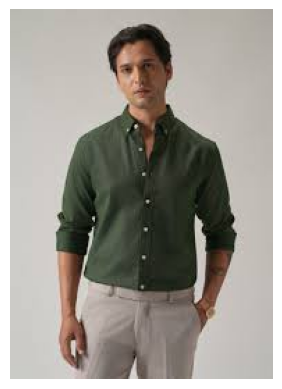

In [2]:
image = cv2.imread("images.jpg")
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.imshow(image)
plt.axis("off")

In [3]:
image = cv2.resize(image, (200, 200))

In [4]:
h, w, _ = image.shape
image = image[int(h*0.2):int(h*0.8), int(w*0.2):int(w*0.8)]

In [5]:
hsv = cv2.cvtColor(image, cv2.COLOR_RGB2HSV)

lower_skin = np.array([0, 20, 70])
upper_skin = np.array([20, 255, 255])
skin_mask = cv2.inRange(hsv, lower_skin, upper_skin)

image[skin_mask > 0] = [0, 0, 0]

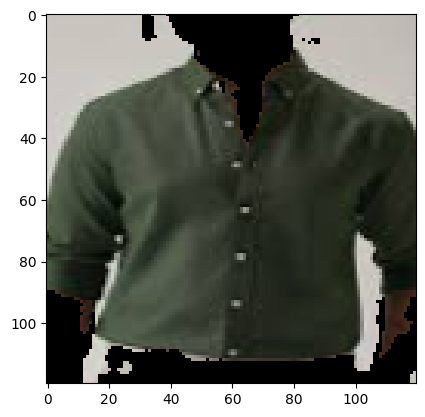

In [6]:
plt.imshow(image)

In [8]:
lower_white = np.array([0, 0, 200])
upper_white = np.array([180, 30, 255])
white_mask = cv2.inRange(hsv, lower_white, upper_white)

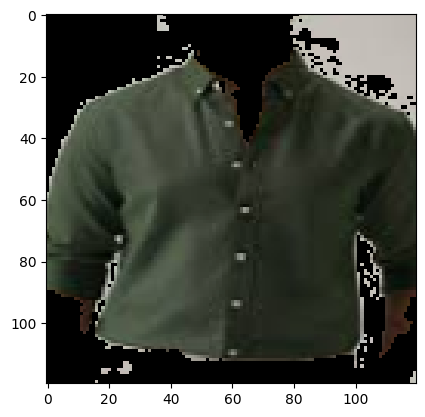

In [9]:
image[white_mask> 0] = [0, 0, 0]
plt.imshow(image)

In [10]:
lower_black = np.array([0, 0, 0])
upper_black = np.array([180, 255, 50])
black_mask = cv2.inRange(hsv, lower_black, upper_black)

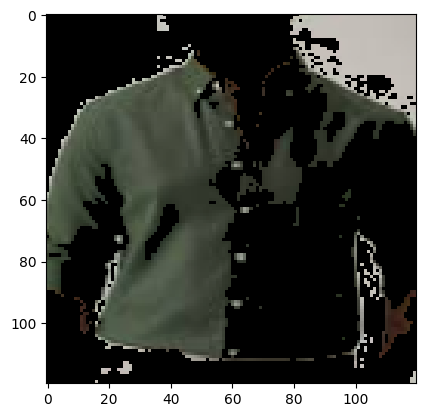

In [11]:
image[black_mask> 0] = [0, 0, 0]
plt.imshow(image)

In [21]:
pixels = image.reshape(-1, 3)
pixels = pixels[np.any(pixels != [0, 0, 0], axis=1)]

kmeans = KMeans(n_clusters=3, n_init=7)
kmeans.fit(pixels)

colors = kmeans.cluster_centers_

In [22]:
colors

array([[ 55.98243464,  60.56821895,  47.59681373],
       [189.27898551, 186.20652174, 178.85235507],
       [ 79.70036541,  88.58424685,  72.76410881]])

In [23]:
hex_colors = [
    '#%02x%02x%02x' % tuple(map(int, c))
    for c in colors
]

print(hex_colors)

['#373c2f', '#bdbab2', '#4f5848']


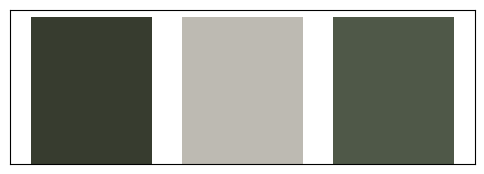

In [24]:
plt.figure(figsize=(6, 2))

for i, color in enumerate(hex_colors):
    plt.bar(i, 1, color=color)

plt.xticks([])
plt.yticks([])
plt.show()

In [29]:

PROMPT_TEMPLATE = """
You are an expert fashion stylist AI.

TASK:
Based on the given color palette and user query, suggest matching outfit recommendations.

USER QUERY:
{user_query}

DETECTED COLORS (from the clothing image):
{colors}

INSTRUCTIONS:

- Do NOT assume access to the image
- Use the provided colors as the source of truth
- If clothing type is unclear, make a reasonable assumption (e.g., shirt, dress, etc.)

- Respond in a natural paragraph format (NOT JSON)
- First briefly describe the color palette
- Then give 3 matching recommendations

Each recommendation must include:
- item
- color name + hex code
- reason
- confidence (0 to 1)

Keep the response clear, practical, and stylist-like.
"""

In [25]:
from langchain_groq import ChatGroq
from langchain_core.messages import HumanMessage
from dotenv import load_dotenv
import os 
load_dotenv()

GROQ_API_KEY = os.environ.get("GROQ_API_KEY")

llm = ChatGroq(
    model="openai/gpt-oss-120b",
    api_key=GROQ_API_KEY,
    temperature=0.3
)

In [27]:
query="what matching thing i need to wear for this shirt"

In [26]:
colors=hex_colors

In [30]:
prompt = PROMPT_TEMPLATE.format(
            user_query=query,
            colors=", ".join(colors) if colors else "Not provided"
        )

In [31]:
response = llm.invoke([
            HumanMessage(content=prompt)
        ])

In [32]:
response

AIMessage(content='The three colors in your shirt form a calm, earthy palette: a deep, muted olive‑gray (#373c2f), a soft, warm greige/taupe (#bdbab2), and a subtle sage‑green (#4f5848). These tones pair beautifully with other natural shades and a few contrasting neutrals, letting you create looks that feel both polished and relaxed.\n\n**1. Trousers – Charcoal Slate\u202f#2F2F2F** – A slim‑fit pair of charcoal trousers will echo the dark undertone of the shirt while keeping the outfit grounded. The near‑black hue provides a sleek silhouette without harsh contrast, making the shirt the focal point. **Confidence: 0.92**\n\n**2. Blazer – Light Olive‑Drab\u202f#8A9A5B** – A lightweight blazer in a lighter olive tone adds a layered dimension that harmonizes with the shirt’s #4f5848 sage accent. The subtle color shift creates depth while staying within the same earthy family, perfect for smart‑casual occasions. **Confidence: 0.88**\n\n**3. Shoes – Suede Tan\u202f#C5A880** – A pair of suede 